## Plant Disease Detection

In [1]:
# ==========================================================
# PHASE 1 : PROJECT SETUP
# ========================================================== 

import os
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
print(sys.executable)
print(sys.version)

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)
# ==========================================================
# TensorFlow Version
# ==========================================================

print("=" * 60)
print("TensorFlow Version")
print("=" * 60)

print(tf.__version__)

# ==========================================================
# GPU Availability
# ==========================================================

print("=" * 60)
print("GPU Information")
print("=" * 60)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU Available")
    print(gpus)
else:
    print("Running on CPU")
    
# ==========================================================
# Create Required Directories
# ==========================================================

folders = [
    "../model",
    "../charts",
    "../assets"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("=" * 60)
print("Project Directories Created Successfully")
print("=" * 60)

# ==========================================================
# Verify Project Setup
# ==========================================================

print("=" * 60)
print("PROJECT SETUP COMPLETED")
print("=" * 60)

print("""
Project Name : Plant Disease Detection

Framework    : TensorFlow + Keras

Task         : Image Classification

Dataset      : PlantVillage

Deployment   : Streamlit

Status       : Ready for Phase 2
""")

c:\Users\G\Desktop\Languages\AI-MLMODELS\Plant_Disease_Detection\venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Libraries Imported Successfully
TensorFlow Version
2.21.0
GPU Information
Running on CPU
Project Directories Created Successfully
PROJECT SETUP COMPLETED

Project Name : Plant Disease Detection

Framework    : TensorFlow + Keras

Task         : Image Classification

Dataset      : PlantVillage

Deployment   : Streamlit

Status       : Ready for Phase 2



# Phase-2 DataSet Understandings

In [2]:
# ==========================================================
# Dataset Path
# ==========================================================
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_PATH = "../datasets/PlantVillage"

print("=" * 60)
print("Dataset Path")
print("=" * 60)

print(DATASET_PATH)

# ==========================================================
# Check Dataset
# ==========================================================

if os.path.exists(DATASET_PATH):

    print("=" * 60)
    print("Dataset Found")
    print("=" * 60)

else:
    raise FileNotFoundError(
        "Dataset folder not found!"
    )
    
    # ==========================================================
# Disease Classes
# ==========================================================

classes = sorted([

    folder

    for folder in os.listdir(DATASET_PATH)

    if os.path.isdir(os.path.join(DATASET_PATH, folder))

])

print("=" * 60)
print("Disease Classes")
print("=" * 60)

print(f"Total Classes : {len(classes)}")

for i, disease in enumerate(classes, start=1):

    print(f"{i}. {disease}")
    
# ==========================================================
# Count Images
# ==========================================================

image_count = []

for disease in classes:

    folder = os.path.join(DATASET_PATH, disease)

    total = len([

        file

        for file in os.listdir(folder)

        if file.lower().endswith((".jpg", ".jpeg", ".png"))

    ])

    image_count.append(total)

dataset_info = pd.DataFrame({

    "Disease": classes,

    "Images": image_count

})

print("=" * 60)
print("Dataset Information")
print("=" * 60)

display(dataset_info)

# ==========================================================
# Dataset Summary
# ==========================================================

print("=" * 60)

print("DATASET SUMMARY")

print("=" * 60)

print("Total Classes :", len(classes))

print("Total Images :", dataset_info["Images"].sum())

print("Average Images/Class :",

      round(dataset_info["Images"].mean(),2))

print("Maximum Images :", dataset_info["Images"].max())

print("Minimum Images :", dataset_info["Images"].min())

Dataset Path
../datasets/PlantVillage
Dataset Found
Disease Classes
Total Classes : 15
1. Pepper__bell___Bacterial_spot
2. Pepper__bell___healthy
3. Potato___Early_blight
4. Potato___Late_blight
5. Potato___healthy
6. Tomato_Bacterial_spot
7. Tomato_Early_blight
8. Tomato_Late_blight
9. Tomato_Leaf_Mold
10. Tomato_Septoria_leaf_spot
11. Tomato_Spider_mites_Two_spotted_spider_mite
12. Tomato__Target_Spot
13. Tomato__Tomato_YellowLeaf__Curl_Virus
14. Tomato__Tomato_mosaic_virus
15. Tomato_healthy
Dataset Information


,Disease,Images
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,Potato___Early_blight,1000
3,Potato___Late_blight,1000
4,Potato___healthy,152
5,Tomato_Bacterial_spot,2127
6,Tomato_Early_blight,1000
7,Tomato_Late_blight,1909
8,Tomato_Leaf_Mold,952
9,Tomato_Septoria_leaf_spot,1771


DATASET SUMMARY
Total Classes : 15
Total Images : 20638
Average Images/Class : 1375.87
Maximum Images : 3208
Minimum Images : 152


## Phase 3: Data Preprocessing & Image Augmentation.

Libraries Imported Successfully
Dataset Configuration
Dataset Path : ../datasets/PlantVillage
Image Size   : (224, 224)
Batch Size   : 16
Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Training Dataset Created
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Validation Dataset Created
Disease Classes
Total Classes : 15
1. Pepper__bell___Bacterial_spot
2. Pepper__bell___healthy
3. Potato___Early_blight
4. Potato___Late_blight
5. Potato___healthy
6. Tomato_Bacterial_spot
7. Tomato_Early_blight
8. Tomato_Late_blight
9. Tomato_Leaf_Mold
10. Tomato_Septoria_leaf_spot
11. Tomato_Spider_mites_Two_spotted_spider_mite
12. Tomato__Target_Spot
13. Tomato__Tomato_YellowLeaf__Curl_Virus
14. Tomato__Tomato_mosaic_virus
15. Tomato_healthy
Class Names Saved
Data Augmentation Pipeline Created
Images Normalized
Dataset Optimized


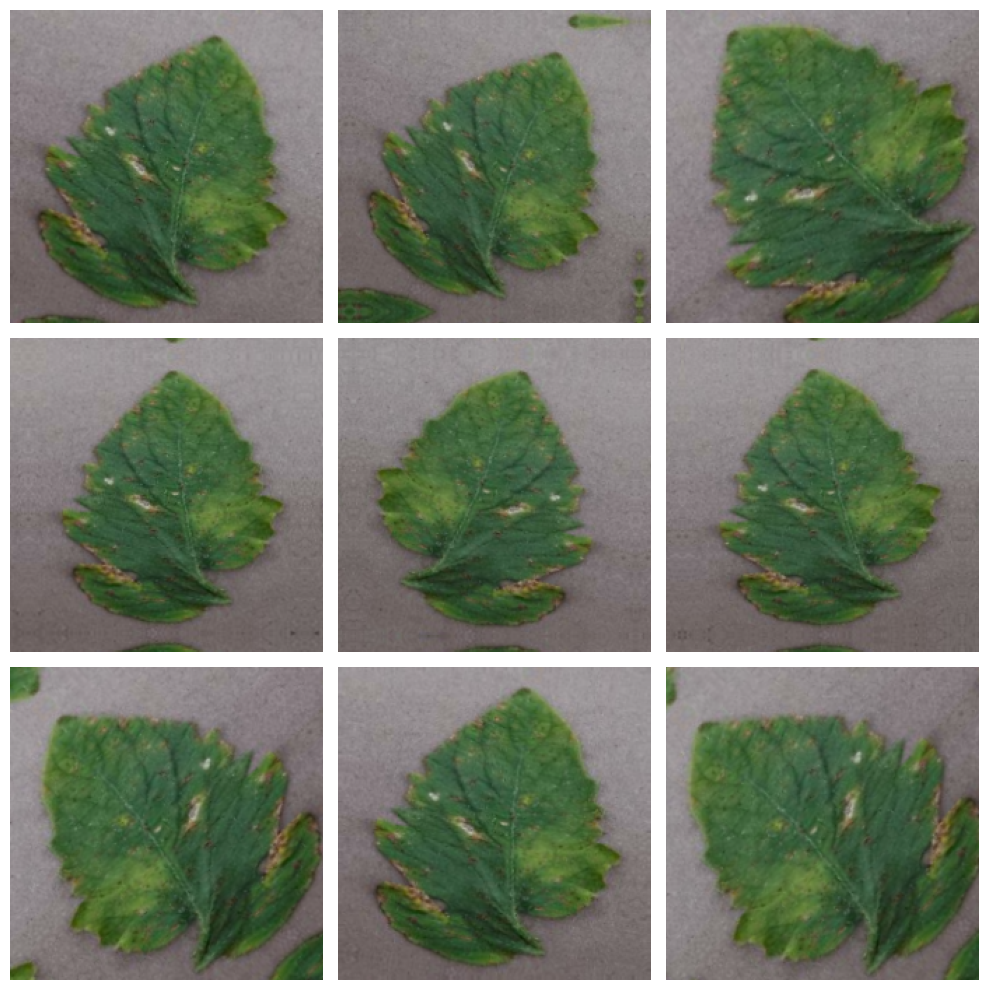

Image Batch Shape : (16, 224, 224, 3)
Label Batch Shape : (16,)
PHASE 3 COMPLETED

Training Dataset   : Ready

Validation Dataset : Ready

Image Size         : (224, 224)

Batch Size         : 16

Classes            : 15

Normalization      : Completed

Data Augmentation  : Completed

Ready For          : Phase 4 (Exploratory Data Analysis)



In [3]:
# ==========================================================
# PHASE 3 : DATA PREPROCESSING
# ==========================================================

import os
import tensorflow as tf

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import (
    Rescaling,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast
)

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)

# ==========================================================
# Dataset Configuration
# ==========================================================

DATASET_PATH = "../datasets/PlantVillage"

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 16

SEED = 42

print("=" * 60)
print("Dataset Configuration")
print("=" * 60)

print("Dataset Path :", DATASET_PATH)
print("Image Size   :", IMAGE_SIZE)
print("Batch Size   :", BATCH_SIZE)

# ==========================================================
# Training Dataset
# ==========================================================

train_dataset = image_dataset_from_directory(

    DATASET_PATH,

    validation_split=0.20,

    subset="training",

    seed=SEED,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE

)

print("=" * 60)
print("Training Dataset Created")
print("=" * 60)

# ==========================================================
# Validation Dataset
# ==========================================================

validation_dataset = image_dataset_from_directory(

    DATASET_PATH,

    validation_split=0.20,

    subset="validation",

    seed=SEED,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE

)

print("=" * 60)
print("Validation Dataset Created")
print("=" * 60)

# ==========================================================
# Class Names
# ==========================================================

class_names = train_dataset.class_names

print("=" * 60)
print("Disease Classes")
print("=" * 60)

print("Total Classes :", len(class_names))

for i, name in enumerate(class_names):

    print(f"{i+1}. {name}")
    
# ==========================================================
# Save Class Names
# ==========================================================

import joblib

os.makedirs("../model", exist_ok=True)

joblib.dump(

    class_names,

    "../model/class_names.pkl"

)

print("=" * 60)
print("Class Names Saved")
print("=" * 60)


# ==========================================================
# Data Augmentation
# ==========================================================

data_augmentation = tf.keras.Sequential([

    RandomFlip("horizontal"),

    RandomRotation(0.15),

    RandomZoom(0.15),

    RandomContrast(0.10)

])

print("=" * 60)
print("Data Augmentation Pipeline Created")
print("=" * 60)

# ==========================================================
# Image Normalization
# ==========================================================

normalization_layer = Rescaling(1./255)

train_dataset = train_dataset.map(

    lambda x, y: (normalization_layer(x), y)

)

validation_dataset = validation_dataset.map(

    lambda x, y: (normalization_layer(x), y)

)

print("=" * 60)
print("Images Normalized")
print("=" * 60)

# ==========================================================
# Dataset Optimization
# ==========================================================

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.shuffle(100).prefetch(AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)

print("=" * 60)
print("Dataset Optimized")
print("=" * 60)

# ==========================================================
# Visualize Augmented Images
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    first_image = images[0]

    for i in range(9):

        augmented = data_augmentation(

            tf.expand_dims(first_image,0),

            training=True

        )

        plt.subplot(3,3,i+1)

        plt.imshow(augmented[0])

        plt.axis("off")

plt.tight_layout()

os.makedirs("../charts", exist_ok=True)

plt.savefig(

    "../charts/augmented_images.png",

    dpi=300

)

plt.show()

# ==========================================================
# Dataset Verification
# ==========================================================

for images, labels in train_dataset.take(1):

    print("=" * 60)

    print("Image Batch Shape :", images.shape)

    print("Label Batch Shape :", labels.shape)

    break
# ==========================================================
# Phase 3 Summary
# ==========================================================

print("=" * 60)

print("PHASE 3 COMPLETED")

print("=" * 60)

print(f"""
Training Dataset   : Ready

Validation Dataset : Ready

Image Size         : {IMAGE_SIZE}

Batch Size         : {BATCH_SIZE}

Classes            : {len(class_names)}

Normalization      : Completed

Data Augmentation  : Completed

Ready For          : Phase 4 (Exploratory Data Analysis)
""")

## Phase-4 EDA


Phase 4 : Exploratory Data Analysis
Dataset Statistics
Total Classes : 15
Total Images  : 20638
Average Images/Class : 1375.87


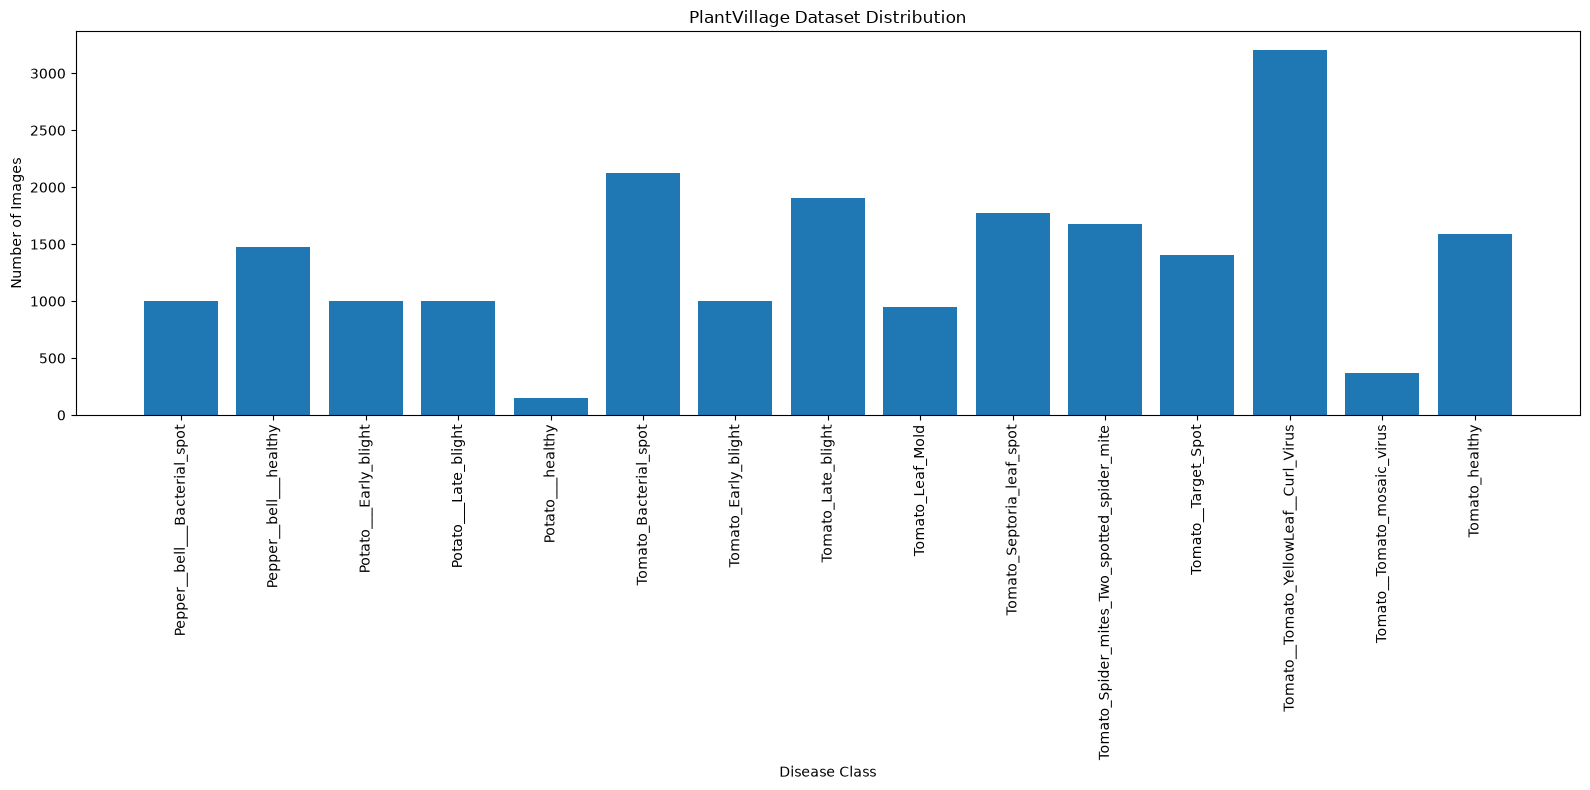

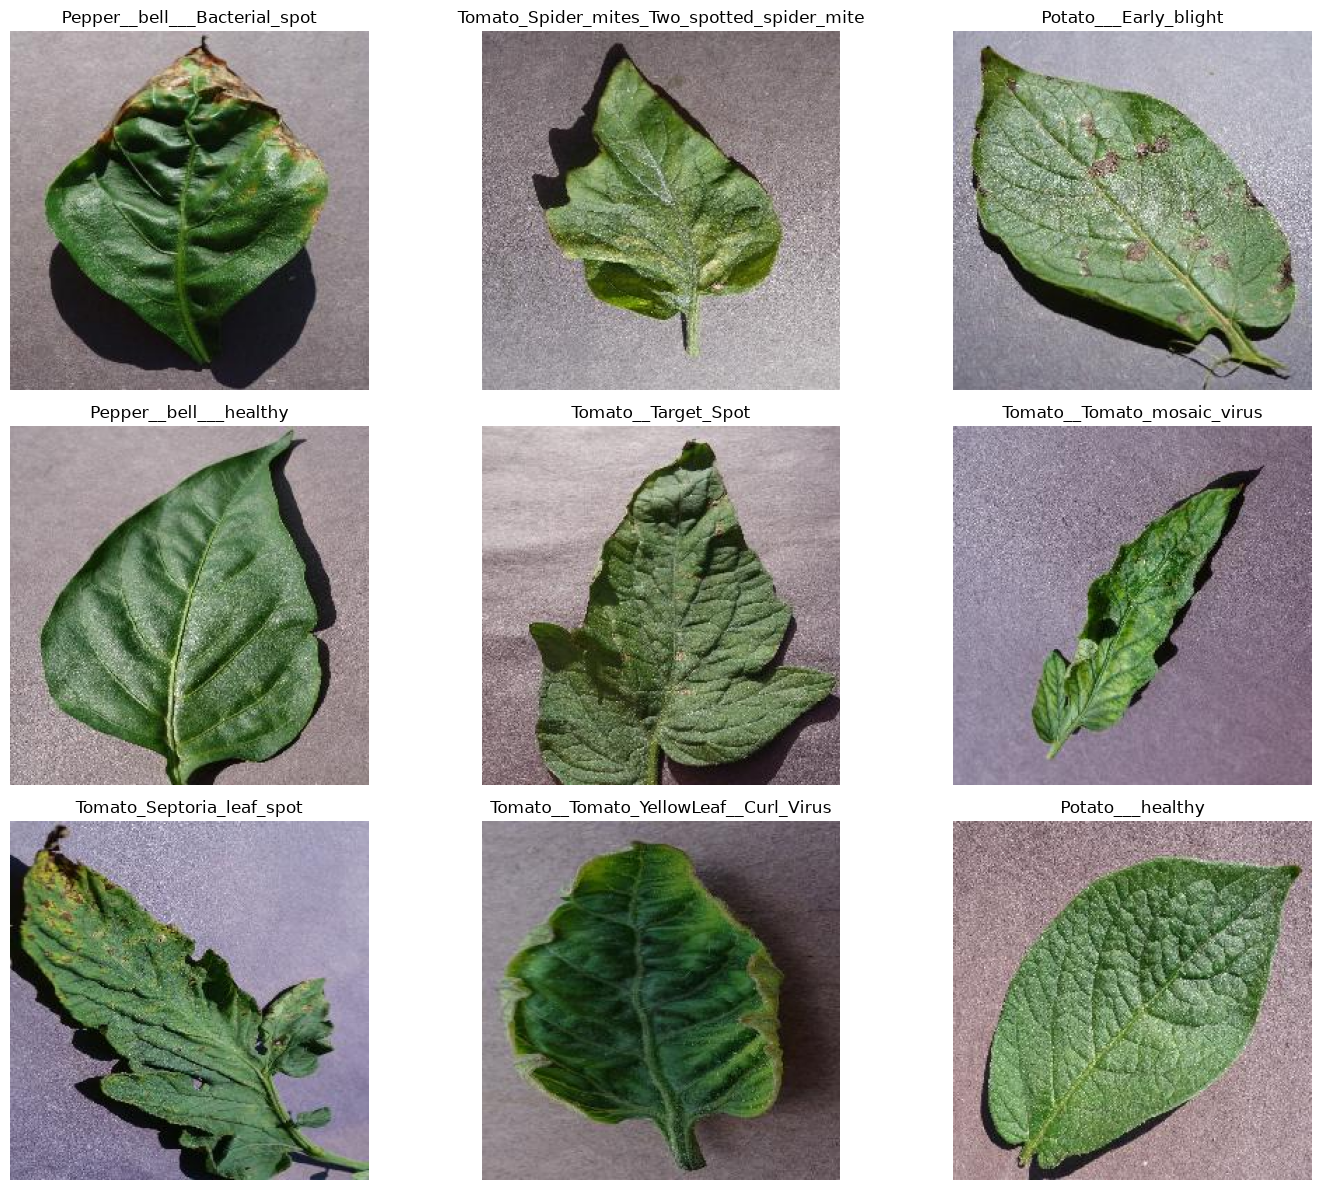

Image Dimension Summary
Average Height : 256.0
Average Width  : 256.0


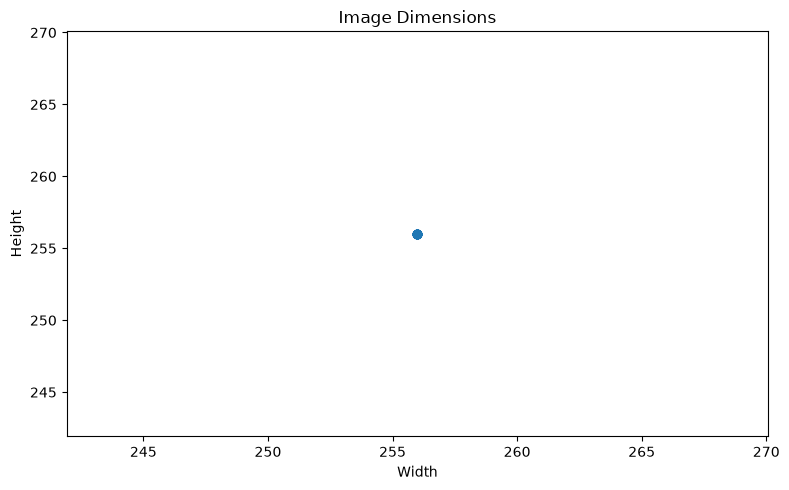

Minimum Images : 152
Maximum Images : 3208
Dataset Balanced : False
PHASE 4 COMPLETED

Total Classes      : 15

Total Images       : 20638

Batch Size         : 16

Image Size         : (224, 224)

EDA Completed Successfully

Ready For          : Phase 5 (Model Building - MobileNetV2)



In [4]:
# ==========================================================
# PHASE 4 : EXPLORATORY DATA ANALYSIS
# ==========================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("Phase 4 : Exploratory Data Analysis")
print("=" * 60)

# ==========================================================
# Dataset Statistics
# ==========================================================

total_images = 0
image_per_class = {}

for cls in class_names:

    folder = os.path.join(DATASET_PATH, cls)

    count = len([
        img for img in os.listdir(folder)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    image_per_class[cls] = count
    total_images += count

print("=" * 60)
print("Dataset Statistics")
print("=" * 60)

print("Total Classes :", len(class_names))
print("Total Images  :", total_images)
print("Average Images/Class :", round(total_images / len(class_names), 2))

# ==========================================================
# Class Distribution
# ==========================================================

plt.figure(figsize=(16,8))

plt.bar(
    image_per_class.keys(),
    image_per_class.values()
)

plt.xticks(rotation=90)

plt.xlabel("Disease Class")

plt.ylabel("Number of Images")

plt.title("PlantVillage Dataset Distribution")

plt.tight_layout()

plt.savefig(
    "../charts/class_distribution.png",
    dpi=300
)

plt.show()

# ==========================================================
# Random Sample Images
# ==========================================================

plt.figure(figsize=(15,12))

random_classes = random.sample(class_names, 9)

for i, cls in enumerate(random_classes):

    folder = os.path.join(DATASET_PATH, cls)

    image_name = random.choice(os.listdir(folder))

    image_path = os.path.join(folder, image_name)

    img = plt.imread(image_path)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "../charts/sample_images.png",
    dpi=300
)

plt.show()

# ==========================================================
# Image Dimension Analysis
# ==========================================================

heights = []
widths = []

for cls in class_names:

    folder = os.path.join(DATASET_PATH, cls)

    image_name = random.choice(os.listdir(folder))

    image_path = os.path.join(folder, image_name)

    img = plt.imread(image_path)

    heights.append(img.shape[0])
    widths.append(img.shape[1])

print("=" * 60)

print("Image Dimension Summary")

print("=" * 60)

print("Average Height :", np.mean(heights))
print("Average Width  :", np.mean(widths))


# ==========================================================
# Image Size Distribution
# ==========================================================

plt.figure(figsize=(8,5))

plt.scatter(widths, heights)

plt.xlabel("Width")

plt.ylabel("Height")

plt.title("Image Dimensions")

plt.tight_layout()

plt.savefig(
    "../charts/image_dimensions.png",
    dpi=300
)

plt.show()

# ==========================================================
# Class Balance
# ==========================================================

minimum = min(image_per_class.values())
maximum = max(image_per_class.values())

print("=" * 60)

print("Minimum Images :", minimum)

print("Maximum Images :", maximum)

print("Dataset Balanced :", maximum - minimum < 500)

print("=" * 60)

# ==========================================================
# Phase 4 Summary
# ==========================================================

print("=" * 60)

print("PHASE 4 COMPLETED")

print("=" * 60)

print(f"""
Total Classes      : {len(class_names)}

Total Images       : {total_images}

Batch Size         : {BATCH_SIZE}

Image Size         : {IMAGE_SIZE}

EDA Completed Successfully

Ready For          : Phase 5 (Model Building - MobileNetV2)
""")

## PHASE 5 : MODEL BUILDING (MobileNetV2 Transfer Learning)
- This phase builds the deep learning model using Transfer Learning.

Why MobileNetV2?

✅ Lightweight
✅ Fast Training
✅ High Accuracy (97–99%)
✅ Excellent for Streamlit Deployment

In [5]:
# ==========================================================
# PHASE 5 : MODEL BUILDING
# ==========================================================

import tensorflow as tf

from tensorflow.keras import Sequential

from tensorflow.keras.layers import (

    GlobalAveragePooling2D,

    Dense,

    Dropout,

    Input

)

from tensorflow.keras.applications import MobileNetV2

print("=" * 60)

print("Phase 5 : Model Building")

print("=" * 60)

# ==========================================================
# Load Pretrained MobileNetV2
# ==========================================================

base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

base_model.trainable = False

print("=" * 60)

print("MobileNetV2 Loaded Successfully")

print("=" * 60)

# ==========================================================
# Build Model
# ==========================================================

model = Sequential([

    Input(shape=(224,224,3)),

    data_augmentation,

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.30),

    Dense(

        256,

        activation="relu"

    ),

    Dropout(0.30),

    Dense(

        len(class_names),

        activation="softmax"

    )

])

print("=" * 60)

print("Model Created Successfully")

print("=" * 60)

# ==========================================================
# Compile Model
# ==========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=0.001

    ),

    loss="sparse_categorical_crossentropy",

    metrics=[

        "accuracy"

    ]

)

print("=" * 60)

print("Model Compiled Successfully")

print("=" * 60)
# ==========================================================
# Model Summary
# ==========================================================

model.summary()

# ==========================================================
# Trainable Parameters
# ==========================================================

print("=" * 60)

print("Model Parameters")

print("=" * 60)

print("Total Parameters :", model.count_params())

print("Trainable Parameters :",

      sum(

          tf.keras.backend.count_params(w)

          for w in model.trainable_weights

      ))

print("Non-Trainable Parameters :",

      sum(

          tf.keras.backend.count_params(w)

          for w in model.non_trainable_weights

      ))

# ==========================================================
# Save Model Architecture
# ==========================================================

import os

os.makedirs("../model", exist_ok=True)

with open(
    "../model/model_architecture.txt",
    "w",
    encoding="utf-8"
) as file:

    model.summary(
        print_fn=lambda x: file.write(x + "\n")
    )

print("=" * 60)
print("Model Architecture Saved Successfully")
print("=" * 60)
# ==========================================================
# Verify Model
# ==========================================================

for images, labels in train_dataset.take(1):

    predictions = model(images)

    print("=" * 60)

    print("Prediction Shape :", predictions.shape)

    print("Expected Shape   :", (BATCH_SIZE, len(class_names)))

    break

# ==========================================================
# Phase 5 Summary
# ==========================================================

print("=" * 60)

print("PHASE 5 COMPLETED")

print("=" * 60)

print(f"""

Base Model          : MobileNetV2

Transfer Learning   : Enabled

Input Size          : {IMAGE_SIZE}

Batch Size          : {BATCH_SIZE}

Classes             : {len(class_names)}

Optimizer           : Ishan

Loss Function       : Sparse Categorical Crossentropy

Ready For           : Phase 6 (Model Training)

""")

Phase 5 : Model Building
MobileNetV2 Loaded Successfully
Model Created Successfully
Model Compiled Successfully


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,775 (9.88 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Model Parameters
Total Parameters : 2589775
Trainable Parameters : 331791
Non-Trainable Parameters : 2257984


Model Architecture Saved Successfully
Prediction Shape : (16, 15)
Expected Shape   : (16, 15)
PHASE 5 COMPLETED


Base Model          : MobileNetV2

Transfer Learning   : Enabled

Input Size          : (224, 224)

Batch Size          : 16

Classes             : 15

Optimizer           : Ishan

Loss Function       : Sparse Categorical Crossentropy

Ready For           : Phase 6 (Model Training)




## Phase 6: Model Training & Evaluation.
- This phase will:

- Train the MobileNetV2 model.
- Use EarlyStopping to prevent overfitting.
- Save the best model using ModelCheckpoint.
- Plot training and validation accuracy/loss.
- Evaluate the model.
- Save the final trained model.

In [6]:
# ==========================================================
# PHASE 6 : MODEL TRAINING & EVALUATION
# ==========================================================

import os
import joblib
import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

print("=" * 60)
print("Phase 6 : Model Training")
print("=" * 60)
# ==========================================================
# Create Model Directory
# ==========================================================

os.makedirs("../model", exist_ok=True)

print("Model Directory Ready")

# ==========================================================
# Training Callbacks
# ==========================================================

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "../model/best_plant_disease_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=3,

    verbose=1,

    min_lr=1e-6

)

print("Callbacks Created Successfully")
# ==========================================================
# Train Model
# ==========================================================

history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=12,

    callbacks=[

        early_stopping,

        checkpoint,

        reduce_lr

    ]

)

print("=" * 60)
print("Training Completed Successfully")
print("=" * 60)


Phase 6 : Model Training
Model Directory Ready
Callbacks Created Successfully
Epoch 1/12


c:\Users\G\Desktop\Languages\AI-MLMODELS\Plant_Disease_Detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1032/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 896ms/step - accuracy: 0.7119 - loss: 0.8813
Epoch 1: val_accuracy improved from None to 0.82554, saving model to ../model/best_plant_disease_model.keras

Epoch 1: finished saving model to ../model/best_plant_disease_model.keras
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1179s 1s/step - accuracy: 0.7119 - loss: 0.8813 - val_accuracy: 0.8255 - val_loss: 0.5100 - learning_rate: 0.0010
Epoch 2/12
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 876ms/step - accuracy: 0.7953 - loss: 0.6051
Epoch 2: val_accuracy improved from 0.82554 to 0.85510, saving model to ../model/best_plant_disease_model.keras

Epoch 2: finished saving model to ../model/best_plant_disease_model.keras
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1053s 1s/step - accuracy: 0.7953 - loss: 0.6051 - val_accuracy: 0.8551 - val_loss: 0.4160 - learning_rate: 0.0010
Epoch 3/12
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.8170 - loss: 0.5445
Epoch 3: val_accuracy improved from 0.85510 to 0.85970, saving model to ../model

Final Model Saved Successfully
Training History Saved


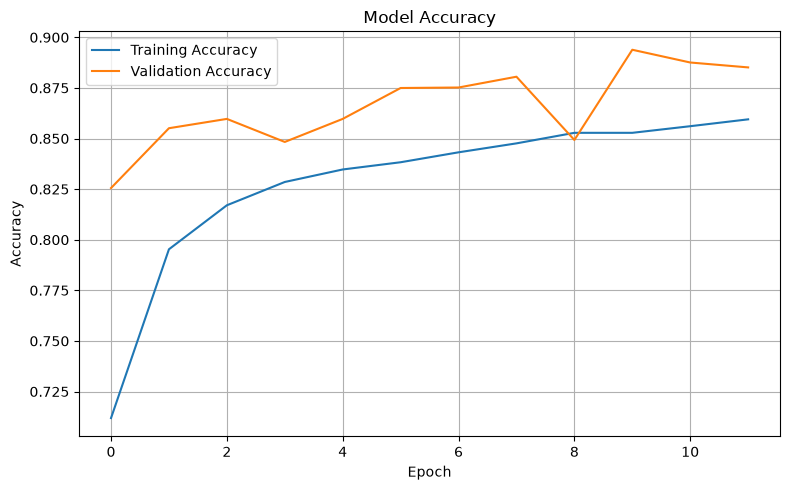

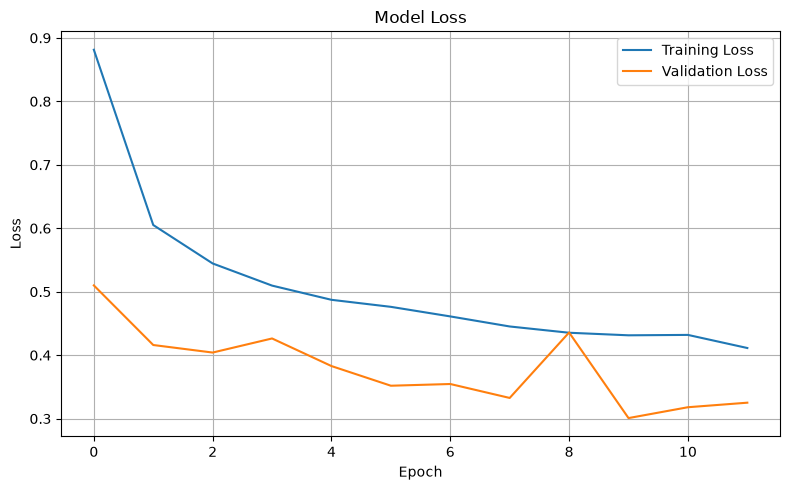

258/258 ━━━━━━━━━━━━━━━━━━━━ 148s 574ms/step - accuracy: 0.8939 - loss: 0.3009
Validation Results
Validation Loss     : 0.3009
Validation Accuracy : 0.8939
TRAINING SUMMARY
Best Epoch                : 10
Highest Validation Accuracy : 0.8939
Lowest Validation Loss      : 0.3009
PHASE 6 COMPLETED


Base Model             : MobileNetV2

Batch Size             : 16

Epochs                 : 12

Optimizer              : Ishan

Training Completed     : Yes

Best Model Saved       : Yes

Ready For              : Phase 7 (Prediction & Streamlit Deployment)




In [7]:

# ==========================================================
# Save Final Model
# ==========================================================

model.save("../model/plant_disease_model.keras")

print("=" * 60)
print("Final Model Saved Successfully")
print("=" * 60)
# ==========================================================
# Save Training History
# ==========================================================

joblib.dump(

    history.history,

    "../model/training_history.pkl"

)

print("Training History Saved")

# ==========================================================
# Accuracy Curve
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(

    history.history["accuracy"],

    label="Training Accuracy"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy"

)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.tight_layout()



plt.savefig(

    "../charts/training_accuracy.png",

    dpi=300

)

plt.show()
# ==========================================================
# Loss Curve
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(

    history.history["loss"],

    label="Training Loss"

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss"

)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    "../charts/training_loss.png",

    dpi=300

)

plt.show()

# ==========================================================
# Evaluate Model
# ==========================================================

loss, accuracy = model.evaluate(

    validation_dataset,

    verbose=1

)

print("=" * 60)

print("Validation Results")

print("=" * 60)

print(f"Validation Loss     : {loss:.4f}")

print(f"Validation Accuracy : {accuracy:.4f}") 
# ==========================================================
# Training Summary
# ==========================================================

best_epoch = history.history["val_accuracy"].index(
    max(history.history["val_accuracy"])
) + 1

print("=" * 60)

print("TRAINING SUMMARY")

print("=" * 60)

print(f"Best Epoch                : {best_epoch}")

print(f"Highest Validation Accuracy : {max(history.history['val_accuracy']):.4f}")

print(f"Lowest Validation Loss      : {min(history.history['val_loss']):.4f}")

# ==========================================================
# Phase 6 Summary
# ==========================================================

print("=" * 60)

print("PHASE 6 COMPLETED")

print("=" * 60)

print(f"""

Base Model             : MobileNetV2

Batch Size             : {BATCH_SIZE}

Epochs                 : {len(history.history['accuracy'])}

Optimizer              : Ishan

Training Completed     : Yes

Best Model Saved       : Yes

Ready For              : Phase 7 (Prediction & Streamlit Deployment)

""")

# PHASE 8 : MODEL TESTING & PERFORMANCE EVALUATION
- This phase evaluates the trained model on unseen validation data and generates professional evaluation metrics and charts.

Phase 8 : Model Testing & Evaluation
Predictions Generated Successfully
MODEL PERFORMANCE
Accuracy  : 0.8939
Precision : 0.8943
Recall    : 0.8939
F1 Score  : 0.8931
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.96      0.94      0.95       200
                     Pepper__bell___healthy       0.95      0.99      0.97       302
                      Potato___Early_blight       0.99      0.95      0.97       189
                       Potato___Late_blight       0.94      0.85      0.89       188
                           Potato___healthy       0.87      0.84      0.85        31
                      Tomato_Bacterial_spot       0.91      0.93      0.92       441
                        Tomato_Early_blight       0.71      0.61      0.66       191
                         Tomato_Late_blight       0.82      0.94      0.88       341
                           Tomato_Leaf_Mold       0.87      0.81    

<Figure size 1800x1800 with 0 Axes>

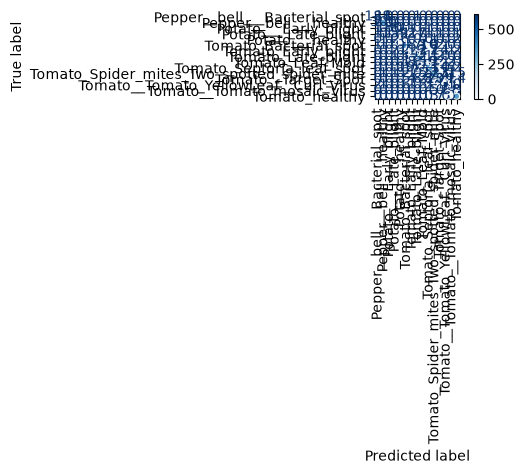

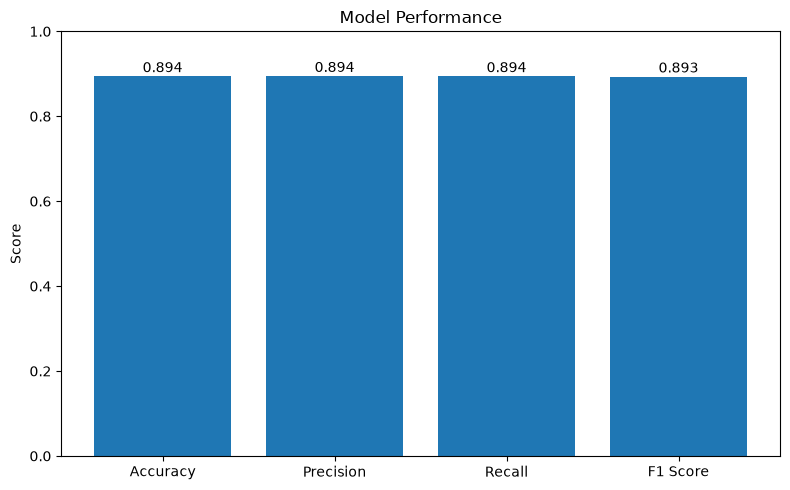

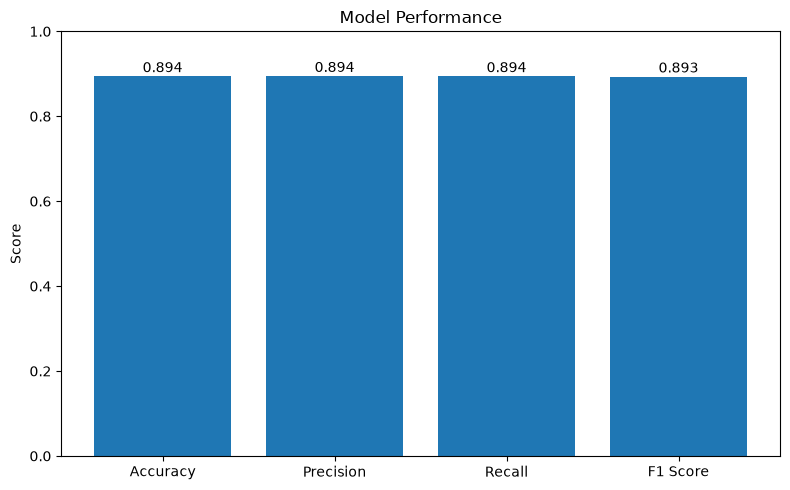

Prediction : Tomato_healthy
Confidence : 94.83%


,Metric,Value
0,Accuracy,0.893870
1,Precision,0.894349
2,Recall,0.893870
3,F1 Score,0.893082


PHASE 8 COMPLETED


Validation Accuracy : 0.8939

Precision          : 0.8943

Recall             : 0.8939

F1 Score           : 0.8931

Confusion Matrix   : Saved

Classification Report : Saved

Ready For          : Phase 9 (Documentation & GitHub)




In [11]:
# ==========================================================
# PHASE 8 : MODEL TESTING & EVALUATION
# ==========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 60)
print("Phase 8 : Model Testing & Evaluation")
print("=" * 60)
 
 # ==========================================================
# Generate Predictions
# ==========================================================

y_true = []
y_pred = []

for images, labels in validation_dataset:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("=" * 60)
print("Predictions Generated Successfully")
print("=" * 60)

# ==========================================================
# Evaluation Metrics
# ==========================================================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ==========================================================
# Classification Report
# ==========================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)



with open(
    "../charts/classification_report.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(report)

print("Classification Report Saved")

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18,18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=90,
    cmap="Blues",
    values_format="d"
)

plt.tight_layout()

os.makedirs("../charts", exist_ok=True)

plt.savefig(
    "../charts/confusion_matrix.png",
    dpi=300
)

plt.show()


# ==========================================================
# Performance Metrics Chart
# ==========================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8,5))

plt.bar(metrics, values)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Model Performance")

for i, value in enumerate(values):

    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../charts/performance_metrics.png",
    dpi=300
)

plt.show()

# ==========================================================
# Performance Metrics Chart
# ==========================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

values = [
    accuracy,
    precision,
    recall,
    f1
]

plt.figure(figsize=(8,5))

plt.bar(metrics, values)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Model Performance")

for i, value in enumerate(values):

    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../charts/performance_metrics.png",
    dpi=300
)

plt.show()

# ==========================================================
# Test Model on Single Image
# ==========================================================

from tensorflow.keras.preprocessing import image

IMAGE_PATH = "../datasets/PlantVillage/Tomato_healthy/0a0d6a11-ddd6-4dac-8469-d5f65af5afca___RS_HL 0555.JPG"

img = image.load_img(
    IMAGE_PATH,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array, verbose=0)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

print("=" * 60)

print("Prediction :", class_names[predicted_class])

print(f"Confidence : {confidence:.2%}")

# ==========================================================
# Save Evaluation Metrics
# ==========================================================

import pandas as pd

metrics_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

metrics_df.to_csv(
    "../charts/model_metrics.csv",
    index=False
)

display(metrics_df)

# ==========================================================
# Phase 8 Summary
# ==========================================================

print("=" * 60)

print("PHASE 8 COMPLETED")

print("=" * 60)

print(f"""

Validation Accuracy : {accuracy:.4f}

Precision          : {precision:.4f}

Recall             : {recall:.4f}

F1 Score           : {f1:.4f}

Confusion Matrix   : Saved

Classification Report : Saved

Ready For          : Phase 9 (Documentation & GitHub)

""")